# 01 - Data Loading & Preparation

Loads every raw data source and saves clean, merged DataFrames to local parquet files.
**Run this notebook first** — all subsequent analysis notebooks read from its outputs.

Outputs written to results:
-  enriched planning-application table
-  all scraped comments with borough formatting
-  Elasticsearch planning-application data

In [1]:
import sys
sys.path.append("../functions")

import pandas as pd
from config import RESULTS_DIR, TOPIC_RUN_DATE
from data_loader import (
    load_comments,
    load_planning_applications,
    load_elasticsearch_planning,
    build_application_df,
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Comments (web-scraped)

In [ ]:
comment_df = pd.read_csv('../data/comments.csv')

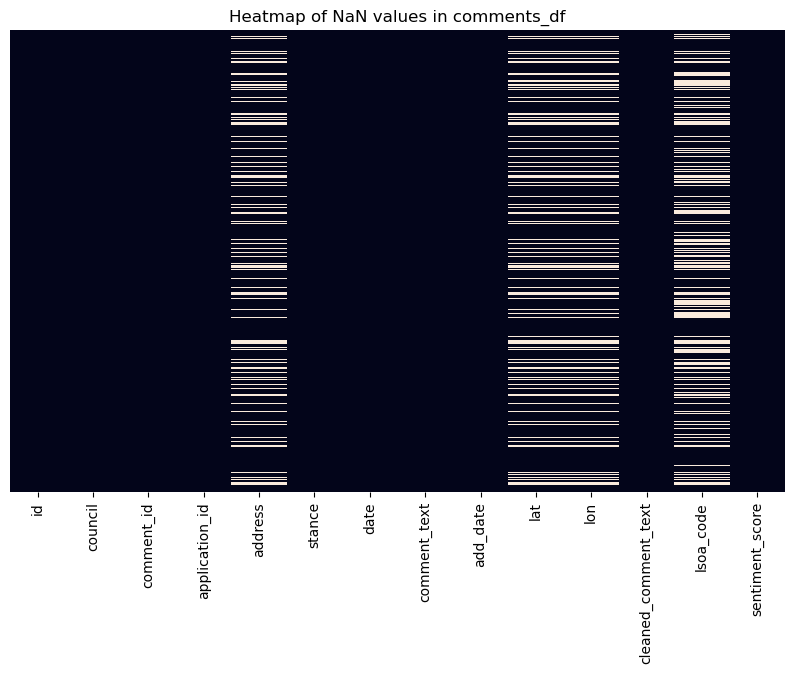

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot heatmap of Nan values in the dataframe
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(comment_df.isna(), cbar=False, yticklabels=False)
plt.title('Heatmap of NaN values in comment_df')
plt.show()
plt.savefig(RESULTS_DIR / f'{TOPIC_RUN_DATE}_comment_df_nan_heatmap.png')

In [ ]:
# data range of comments_df
comment_df['date'] = pd.to_datetime(comment_df['date'], errors='coerce')
print(f"Data range of comment_df: {comment_df['date'].min()} to {comment_df['date'].max()}")

Data range of comments_df: 2016-09-10 00:00:00 to 2025-03-13 00:00:00


## 2. Planning applications (CSV)

In [3]:
application_df = load_planning_applications()
print(f"Loaded {len(application_df):,} applications")
application_df.head()

Loaded 5,077 applications


,lpa_app_no,valid_date,decision_date,borough,application_details.residential_details.total_no_proposed_residential_units,application_details.residential_details.total_no_affordable_units,application_details.residential_details.site_area,application_details.residential_details.habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description
0,24/02204/FUL,2024-11-19 00:00:00,2025-03-25 00:00:00,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...
1,25/0089,2025-01-27 00:00:00,2025-03-24 00:00:00,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...
2,24/1783,2024-08-05 00:00:00,2025-03-24 00:00:00,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...
3,25/00205/PRECOU,2025-02-03 00:00:00,2025-03-25 00:00:00,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...
4,25/00181/PRECOU,2025-01-30 00:00:00,2025-03-26 00:00:00,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...


## 3. Elasticsearch planning data

In [4]:
pld_df = load_elasticsearch_planning()
print(f"Loaded {len(pld_df):,} records from Elasticsearch")
pld_df.head()

Connected to Elastic Search
Loaded 28,804 records from Elasticsearch


,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units,...,total_no_affordable_units,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type
0,Islington,5300030656,NaT,None,PP-13650297,None,"[[[-0.131906, 51.565624], [-0.131907, 51.56559...",Polygon,0,14,...,NaN,NaN,NaN,0,0,0,0,7,0,Market housing
1,Ealing,12103832,2024-05-02,Approved,PP-12236822,,"[[[-0.26669, 51.523306], [-0.266691, 51.523279...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,0,2,Market housing
2,Barnet,000200035046,NaT,Refused,PP-11237089,EN4 8RE,"[[[-0.168816, 51.648135], [-0.168817, 51.64810...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,2,0,Market housing
3,Waltham Forest,None,NaT,Approved,PP-09963632,None,"[[[-0.0106301, 51.5628966], [-0.01062739999999...",Polygon,0,1,...,NaN,NaN,NaN,0,0,0,0,1,0,Market housing
4,Hillingdon,None,NaT,Approved,11138071,HA4 8JB,"[[[-0.42457219999999996, 51.574421], [-0.42408...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,0,2,Market housing


## 4. Build enriched application table

In [5]:
enriched_app_df = build_application_df(application_df, pld_df, comment_df)
print(f"Enriched application table: {len(enriched_app_df):,} rows")
enriched_app_df.head()

Enriched application table: 5,235 rows


,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,housing_type,comment_count
0,24/02204/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...,Market housing,1
1,25/0089,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...,Market housing,0
2,24/1783,NaT,NaT,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...,Market housing,5
3,25/00205/PRECOU,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...,Market housing,0
4,25/00181/PRECOU,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...,Market housing,1


## 5. Save outputs

In [6]:
comment_df.to_parquet(RESULTS_DIR / "comments.parquet", index=False)
enriched_app_df.to_parquet(RESULTS_DIR / "applications.parquet", index=False)
pld_df.to_parquet(RESULTS_DIR / "pld.parquet", index=False)
print("Saved: comments.parquet, applications.parquet, pld.parquet")

Saved: comments.parquet, applications.parquet, pld.parquet
